In [ ]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

from PIL import Image
import cv2

from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv("HAM10000_metadata.csv")

In [ ]:
!ls

HAM10000_metadata.csv  hmnist_28_28_RGB.csv  hmnist_8_8_RGB.csv
hmnist_28_28_L.csv     hmnist_8_8_L.csv      sample_data


In [ ]:
df['dx'].value_counts()

,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


1. METADATA EDA

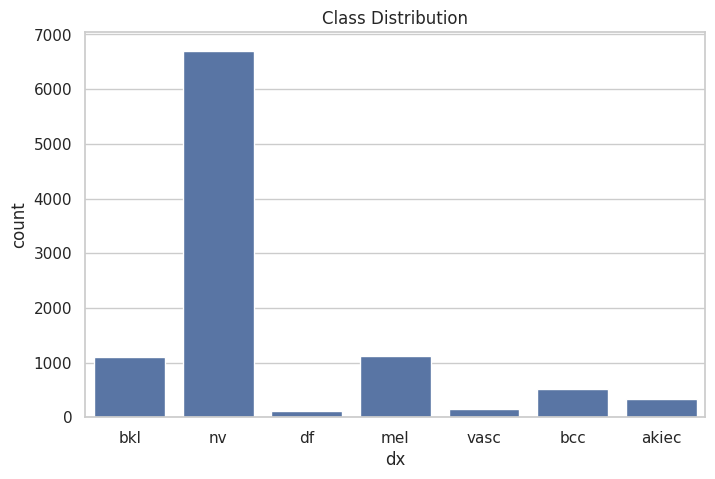

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='dx')
plt.title("Class Distribution")
plt.show()

Class Imbalance

In [ ]:
class_counts = df['dx'].value_counts()
class_percent = df['dx'].value_counts(normalize=True) * 100

imbalance_df = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percent
})

print(imbalance_df)

       Count  Percentage
dx                      
nv      6705   66.949576
mel     1113   11.113330
bkl     1099   10.973540
bcc      514    5.132302
akiec    327    3.265102
vasc     142    1.417873
df       115    1.148278


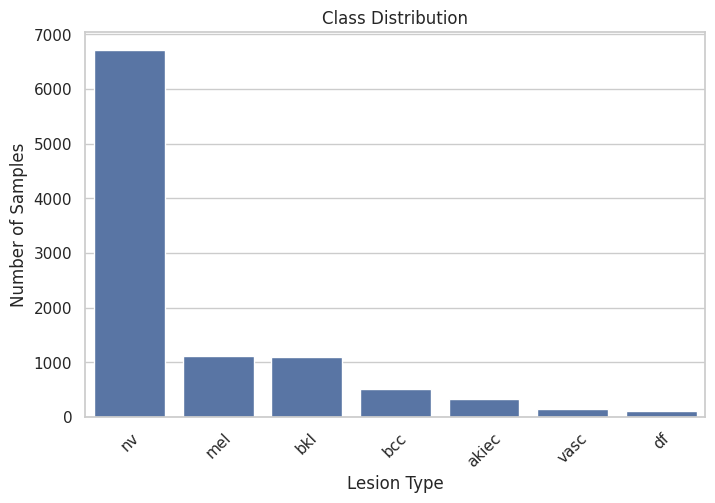

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Lesion Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()

missing values

In [ ]:
df.isnull().sum()

,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,57
sex,0
localization,0


age vs diagnosis

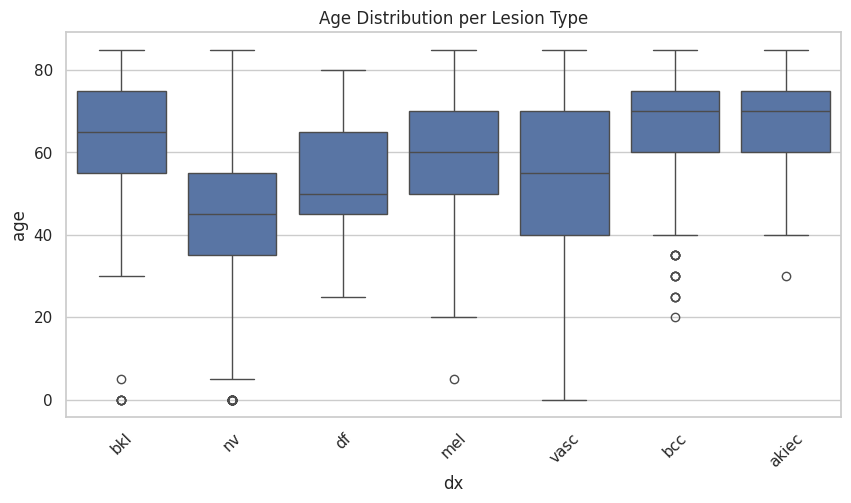

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='dx', y='age')
plt.xticks(rotation=45)
plt.title("Age Distribution per Lesion Type")
plt.show()

sex vs diagnosis

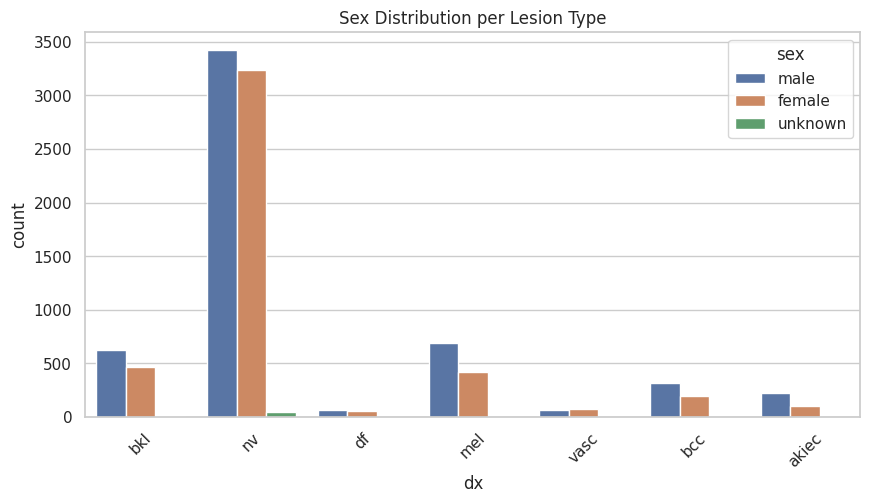

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='dx', hue='sex')
plt.xticks(rotation=45)
plt.title("Sex Distribution per Lesion Type")
plt.show()

Localization vs diagnosis

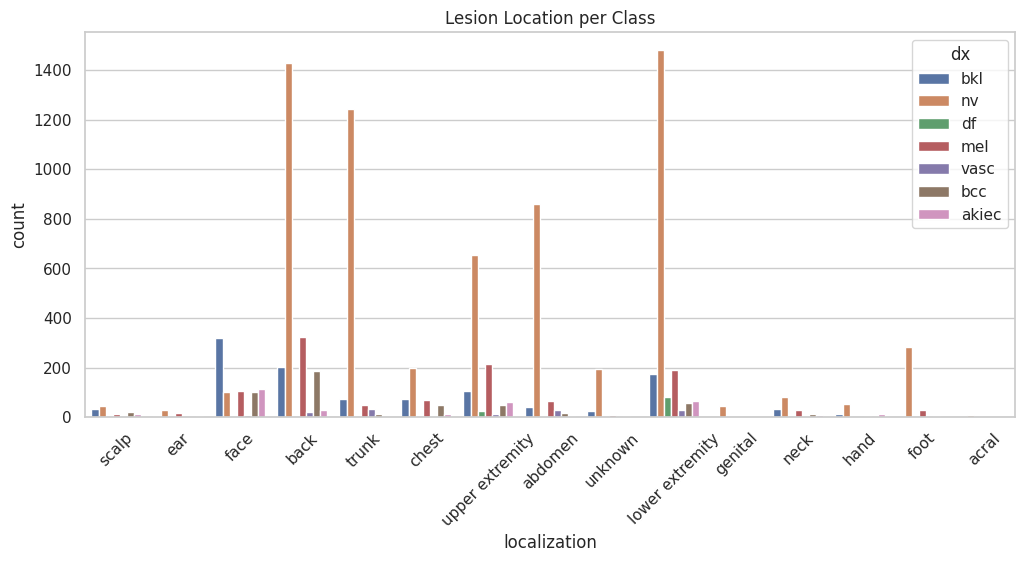

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='localization', hue='dx')
plt.xticks(rotation=45)
plt.title("Lesion Location per Class")
plt.show()

In [ ]:
print(df.columns)

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')


In [ ]:
df['lesion_id'].value_counts().describe()

,count
count,7470.000000
mean,1.340696
std,0.633970
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,6.000000


lesions with mutiple images/duplicates

In [ ]:
dup_count = (df['lesion_id'].value_counts() > 1).sum()
print("Lesions with multiple images:", dup_count)

Lesions with multiple images: 1956


 dataset contains 7,470 unique lesions and 1,956 of them have more than one image which is about 26%

this is actually important because if we randomly split the data by image the same lesion could appear in both training and testing sets so that would lead to data leakage and artificially high performance therefore we will split the dataset based on lesion_id to avoid this issue


In [ ]:
df['dx_type'].value_counts()

,count
dx_type,
histo,5340
follow_up,3704
consensus,902
confocal,69


Histopathology = biopsy confirmed (more reliable)

Follow_up = clinical observation (less certain)

Consensus = expert agreement

Confocal = imaging method

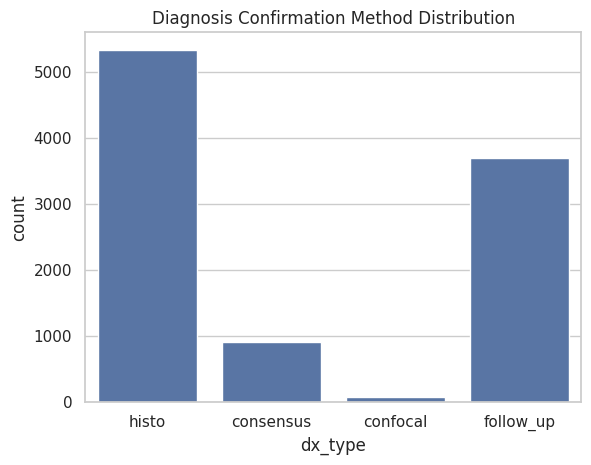

In [ ]:
sns.countplot(data=df, x='dx_type')
plt.title("Diagnosis Confirmation Method Distribution")
plt.show()

repeating these to get the numbers

class vs dx_type

In [ ]:
pd.crosstab(df['dx'], df['dx_type'])

dx_type,confocal,consensus,follow_up,histo
dx,,,,
akiec,0,0,0,327
bcc,0,0,0,514
bkl,69,264,0,766
df,0,60,0,55
mel,0,0,0,1113
nv,0,503,3704,2498
vasc,0,75,0,67


In [ ]:
pd.crosstab(df['dx'], df['sex'])

sex,female,male,unknown
dx,,,
akiec,106,221,0
bcc,197,317,0
bkl,463,626,10
df,52,63,0
mel,424,689,0
nv,3237,3421,47
vasc,73,69,0


In [ ]:
pd.crosstab(df['dx'], df['localization'])

localization,abdomen,acral,back,chest,ear,face,foot,genital,hand,lower extremity,neck,scalp,trunk,unknown,upper extremity
dx,,,,,,,,,,,,,,,
akiec,5,0,29,12,3,113,0,0,13,65,10,14,1,0,62
bcc,18,0,186,47,0,101,4,0,2,58,14,19,11,5,49
bkl,42,0,202,74,6,319,1,2,14,174,31,34,73,23,104
df,4,0,2,0,0,0,2,1,0,82,0,0,0,0,24
mel,66,0,324,68,17,104,28,0,1,192,29,14,47,10,213
nv,860,7,1427,200,30,100,284,45,55,1479,81,45,1241,196,655
vasc,27,0,22,6,0,8,0,0,5,27,3,2,31,0,11


In [ ]:
pd.crosstab(df['dx'], df['dx_type'])

dx_type,confocal,consensus,follow_up,histo
dx,,,,
akiec,0,0,0,327
bcc,0,0,0,514
bkl,69,264,0,766
df,0,60,0,55
mel,0,0,0,1113
nv,0,503,3704,2498
vasc,0,75,0,67


2. Image EDA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
image_dir_1 = "/content/drive/MyDrive/HAM10000_images_part_1"
image_dir_2 = "/content/drive/MyDrive/HAM10000_images_part_2"

In [ ]:
import os

print("Part 1:", len(os.listdir(image_dir_1)))
print("Part 2:", len(os.listdir(image_dir_2)))

Part 1: 5013
Part 2: 5031


connect metadata to image

In [ ]:
image_paths = {}

for folder in [image_dir_1, image_dir_2]:
    for img in os.listdir(folder):
        image_paths[img.split(".")[0]] = os.path.join(folder, img)

df["image_path"] = df["image_id"].map(image_paths)

df[['image_id', 'image_path']].head()

,image_id,image_path
0,ISIC_0027419,/content/drive/MyDrive/HAM10000_images_part_1/...
1,ISIC_0025030,/content/drive/MyDrive/HAM10000_images_part_1/...
2,ISIC_0026769,/content/drive/MyDrive/HAM10000_images_part_1/...
3,ISIC_0025661,/content/drive/MyDrive/HAM10000_images_part_1/...
4,ISIC_0031633,/content/drive/MyDrive/HAM10000_images_part_2/...


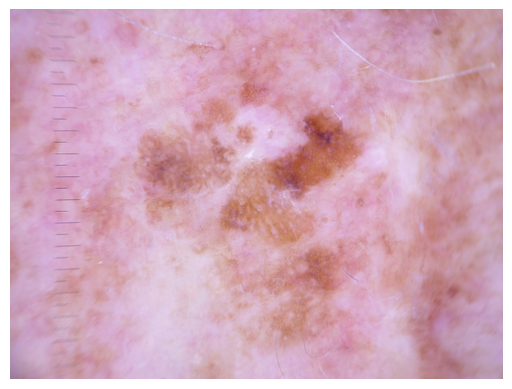

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(df["image_path"].iloc[0])
plt.imshow(img)
plt.axis("off")
plt.show()

image size/resolution consistency

In [ ]:
from PIL import Image
import random

sizes = []

sample_ids = random.sample(list(df["image_path"]), 100)

for path in sample_ids:
    img = Image.open(path)
    sizes.append(img.size)

print(set(sizes))

{(600, 450)}


we can reset this to 224×224 for resNet

randomness in images per class

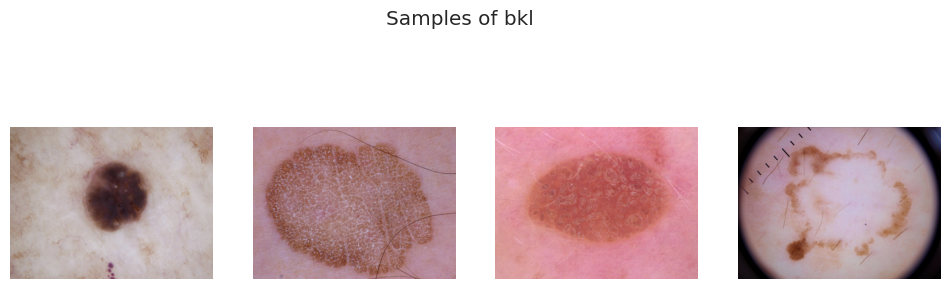

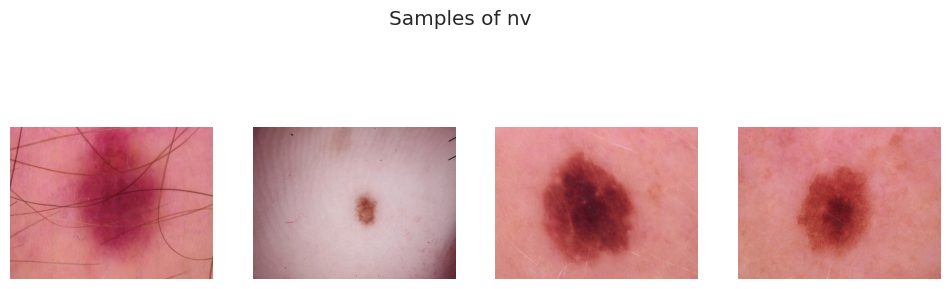

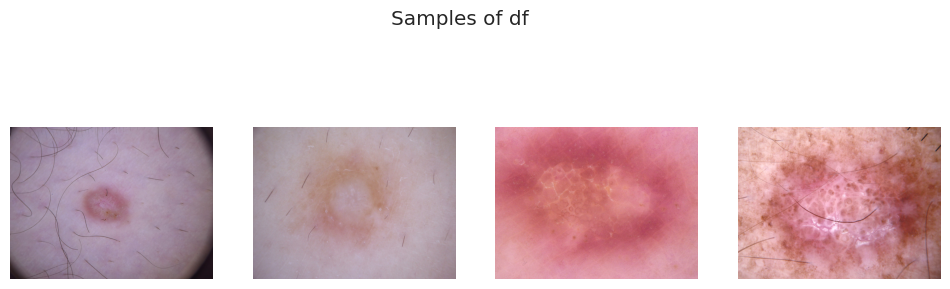

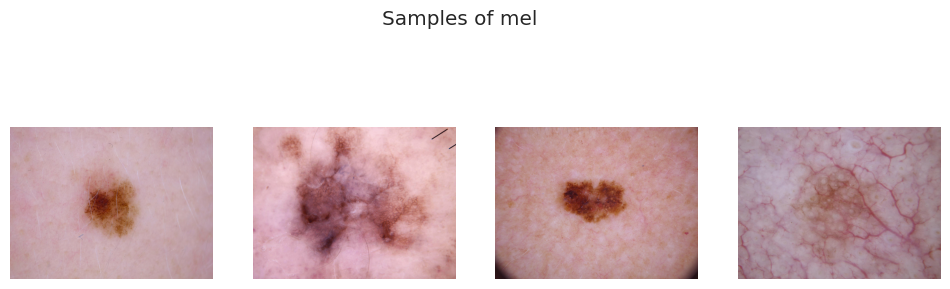

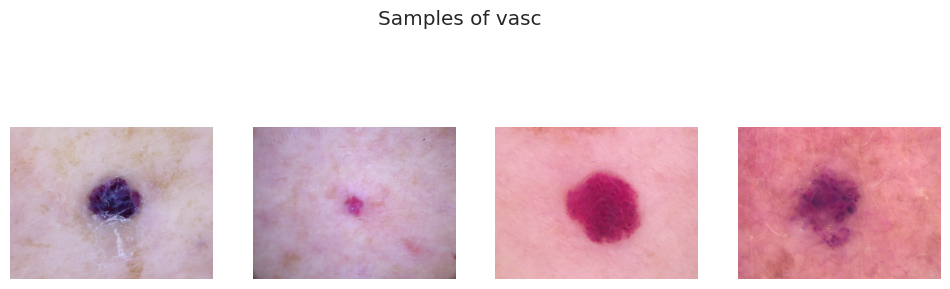

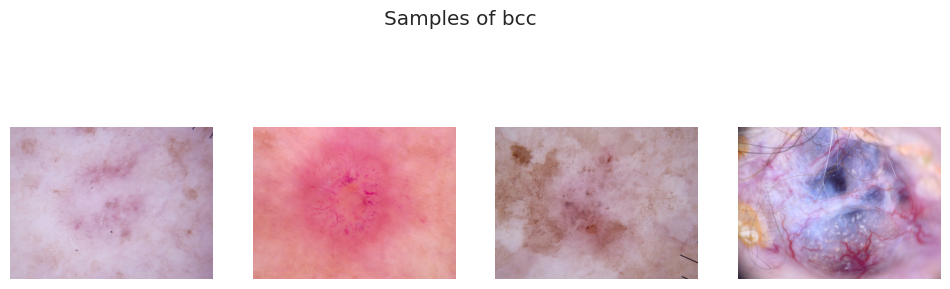

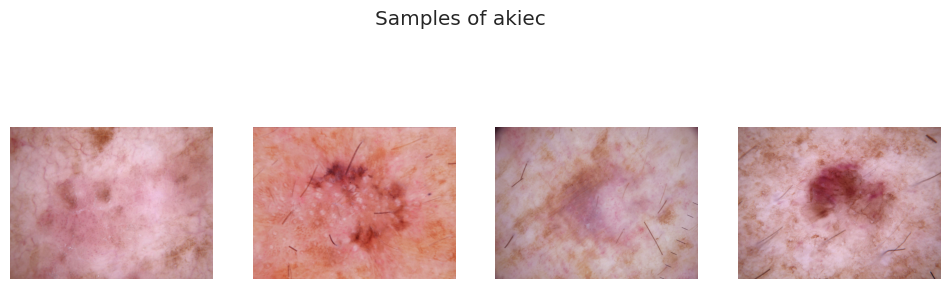

In [ ]:
import matplotlib.pyplot as plt
import random

def show_samples(label, n=4):
    subset = df[df['dx'] == label]
    sample_paths = subset['image_path'].sample(n)

    plt.figure(figsize=(12,4))
    for i, path in enumerate(sample_paths):
        img = Image.open(path)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(f"Samples of {label}")
    plt.show()

for label in df['dx'].unique():
    show_samples(label)

brightness distribution

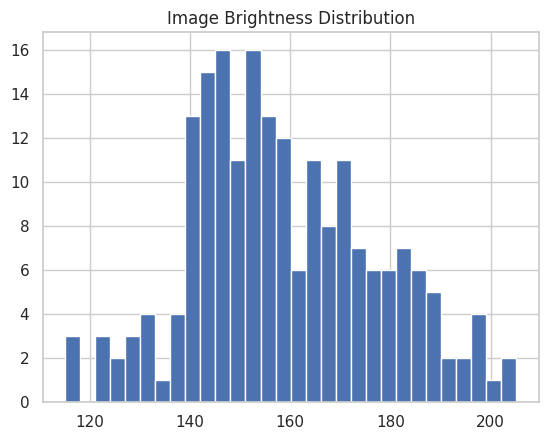

In [ ]:
import numpy as np

brightness = []

for path in random.sample(list(df["image_path"]), 200):
    img = Image.open(path)
    img_array = np.array(img)
    brightness.append(img_array.mean())

plt.hist(brightness, bins=30)
plt.title("Image Brightness Distribution")
plt.show()

for data augumentation we can use brightness variation

ratio consistency

In [ ]:
ratios = []

for path in random.sample(list(df["image_path"]), 200):
    img = Image.open(path)
    w, h = img.size
    ratios.append(w / h)

print(min(ratios), max(ratios))

1.3333333333333333 1.3333333333333333


pixel value range

In [ ]:
import numpy as np

sample = Image.open(df["image_path"].iloc[0])
arr = np.array(sample)

print(arr.min(), arr.max())

43 255


Age Distribution histogram

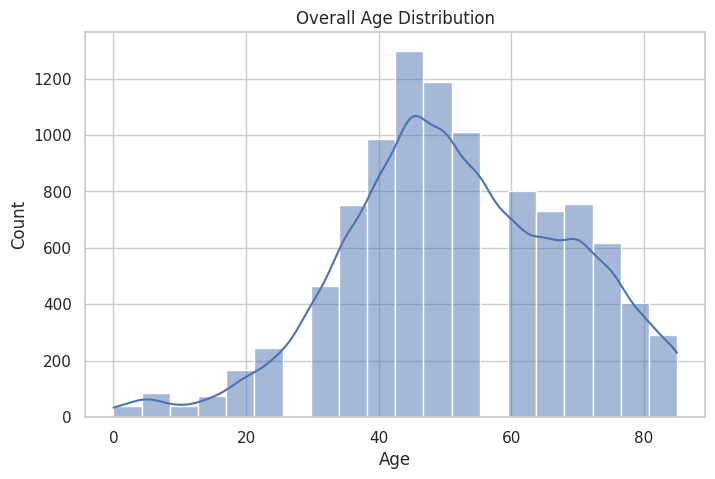

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['age'].dropna(), bins=20, kde=True)
plt.title("Overall Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

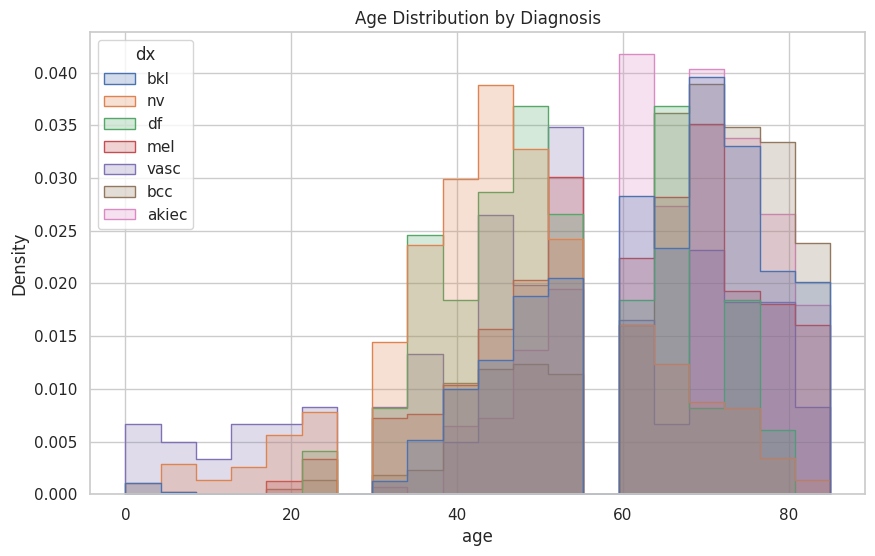

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='age', hue='dx', bins=20, element='step', stat='density', common_norm=False)
plt.title("Age Distribution by Diagnosis")
plt.show()

Is sex distribution significantly different across lesion classes?

If p < 0.05 → sex and diagnosis are statistically associated.

If p ≥ 0.05 → no strong association.

In [ ]:
from scipy.stats import chi2_contingency

sex_dx_table = pd.crosstab(df['dx'], df['sex'])

#  Chi-square test
chi2, p, dof, expected = chi2_contingency(sex_dx_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)

Chi-square statistic: 106.90381271641068
p-value: 2.4464388098587195e-17


Does mean age differ significantly across lesion types?

If p < 0.05 → age distribution significantly differs between classes.

If p ≥ 0.05 → no strong age difference.

In [ ]:
from scipy.stats import f_oneway

# Drop missing ages
df_age = df.dropna(subset=['age'])

# Create list of age groups per class
groups = [group['age'].values for name, group in df_age.groupby('dx')]

# Perform ANOVA
f_stat, p_val = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_val)

F-statistic: 470.1174435547912
p-value: 0.0


The analysis shows that age and sex are closely linked to the type of skin lesion, meaning certain conditions are more common in specific age groups or genders. This suggests that including demographic information can help the model make more accurate predictions.

Lesion-Level Split

In [ ]:
from sklearn.model_selection import train_test_split

# Get unique lesions
lesions = df['lesion_id'].unique()

# Split lesions (stratify by dx at lesion level)
lesion_df = df.groupby('lesion_id')['dx'].first().reset_index()

train_lesions, test_lesions = train_test_split(
    lesion_df,
    test_size=0.2,
    stratify=lesion_df['dx'],
    random_state=42
)

# Assign back to original dataframe
train_df = df[df['lesion_id'].isin(train_lesions['lesion_id'])]
test_df = df[df['lesion_id'].isin(test_lesions['lesion_id'])]

# Image/data preprocessing

median impudation for age

In [ ]:
train_median_age = train_df['age'].median()
train_df['age'] = train_df['age'].fillna(train_median_age)
test_df['age']  = test_df['age'].fillna(train_median_age)

/tmp/ipykernel_531/527467349.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['age'] = train_df['age'].fillna(train_median_age)
/tmp/ipykernel_531/527467349.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['age']  = test_df['age'].fillna(train_median_age)



image resize to 224*224 and scale btn 0to1

In [ ]:
from PIL import Image
import numpy as np

img = Image.open(path)
img = img.resize((224, 224))

img = np.array(img)
img = img.astype("float32")
img = img / 255.0

One-Hot Encode Sex

In [ ]:
train_df = pd.get_dummies(train_df, columns=['sex'])
test_df  = pd.get_dummies(test_df, columns=['sex'])

One-Hot Encode Localization

In [ ]:
train_df = pd.get_dummies(train_df, columns=['localization'])
test_df  = pd.get_dummies(test_df, columns=['localization'])

In [ ]:
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

normalise age

In [ ]:
train_mean = train_df['age'].mean()
train_std  = train_df['age'].std()

# normalization
train_df['age'] = (train_df['age'] - train_mean) / train_std
test_df['age']  = (test_df['age'] - train_mean) / train_std

In [ ]:
print(train_df['age'].mean())
print(train_df['age'].std())

1.9853008957248652e-16
0.9999999999999819


Handcrafted Features

In [ ]:
def extract_color_features(image):

    mean_r = np.mean(image[:,:,0])
    mean_g = np.mean(image[:,:,1])
    mean_b = np.mean(image[:,:,2])

    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    mean_hue = np.mean(hsv[:,:,0])
    hue_var = np.var(hsv[:,:,0])

    mean_sat = np.mean(hsv[:,:,1])
    sat_var = np.var(hsv[:,:,1])

    return [
        mean_r, mean_g, mean_b,
        mean_hue, hue_var,
        mean_sat, sat_var
    ]